Brandon Jackson, Allyanna Panganiban, Karen Sabile
<br> SYSEN 5211 Final Project
<br> Spring 2026

In [2]:
# library imports
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import math
import random
import matplotlib.pyplot as plt

In [3]:
shifts = ['Day', 'Evening', 'Night', ]
n_shifts = len(shifts)
num_nurses = 22
patients = [56, 30, 50]

m = gp.Model('hospital_lp')

# continuous decision variables: the number of nurses assigned to each department
nurse_count = {}
for s, shift in enumerate(shifts):
    nurse_count[s] = m.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f'{shift}')

# binary decision variables: three for every nurse (to cover all three departments)
nurses = []
for n in range(num_nurses):
    nurses.append([])
    for shift in shifts:
        nurses[n].append(m.addVar(lb=0.0, vtype=GRB.BINARY, name=f'{n}_{shift}'))

# objective function: maximize minimum shift coverage
w = m.addVar(lb=0.0, name="max_patients_per_nurse")

for s in range(n_shifts):
    m.addConstr(
        patients[s] <= w * gp.quicksum(nurses[n][s] for n in range(num_nurses))
    )

m.setObjective(w, GRB.MINIMIZE)

# each nurse assigned to one shift
for n in range(num_nurses):
    m.addConstr(gp.quicksum(nurses[n][s] for s in range(n_shifts)) == 1)

# link continuous decision variables to binary decision variables
for s in range(n_shifts):
    m.addConstr(nurse_count[s] == gp.quicksum(nurses[n][s] for n in range(num_nurses)))

m.optimize()

# -----------------------------
# Results
# -----------------------------
if m.status == GRB.OPTIMAL:
    print("\n✅ Optimal solution found:")
    for s, shift in enumerate(shifts):
        print(f"  {shift} Shift: {math.ceil(nurse_count[s].X)} nurses")  # integer format
        print(f"     Nurse-to-Patient Ratio -> 1:{1/(nurse_count[s].X/patients[s]):,.2f}")
    print(f"  Lowest Ratio -> 1:{1/(1/m.ObjVal):,.2f}")
else:
    print(f"❌ Optimization ended with status {m.status}.")

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D2057)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 25 rows, 70 columns and 135 nonzeros (Min)
Model fingerprint: 0xa9c2f5ba
Model has 1 linear objective coefficients
Model has 3 quadratic constraints
Variable types: 4 continuous, 66 integer (66 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [3e+01, 6e+01]

Presolve removed 3 rows and 3 columns
Presolve time: 0.00s
Presolved: 157 rows, 265 columns, 462 nonzeros
Presolved model has 132 SOS constraint(s)
Variable types: 133 continuous, 132 integer (132 binary)
Found heuristic solution: objective 56.0000000
Found heuristic solution: objective 50.00

#### Feasibility Test

In [5]:
nominal_day = nurse_count[0].X
nominal_evening = nurse_count[1].X
nominal_night = nurse_count[2].X
nominal_z = 1/m.ObjVal

feasible_count = 0

for i in range(100):
  if nominal_day / random.uniform(40, 72) >= nominal_z and nominal_evening / random.uniform(18, 42) \
      >= nominal_z and nominal_night / random.uniform(37, 63):
    feasible_count += 1

print(f'Feasibility rate for 100 samples: {feasible_count}%')

Feasibility rate for 100 samples: 25%


#### Worst-Case Scenario

In [6]:
worst_case_num_patients = [72, 42, 63]

rm = gp.Model('robust_lp')

# continuous decision variables: the number of nurses assigned to each department
nurse_count = {}
for s, shift in enumerate(shifts):
    nurse_count[s] = rm.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f'{shift}')

# binary decision variables: three for every nurse (to cover all three departments)
nurses = []
for n in range(num_nurses):
    nurses.append([])
    for shift in shifts:
        nurses[n].append(rm.addVar(lb=0.0, vtype=GRB.BINARY, name=f'{n}_{shift}'))

# objective function: maximize minimum shift coverage
w = rm.addVar(lb=0.0, name="max_patients_per_nurse")

for s in range(n_shifts):
    rm.addConstr(
        worst_case_num_patients[s] <= w * gp.quicksum(nurses[n][s] for n in range(num_nurses))
    )

rm.setObjective(w, GRB.MINIMIZE)

# each nurse assigned to one shift
for n in range(num_nurses):
    rm.addConstr(gp.quicksum(nurses[n][s] for s in range(n_shifts)) == 1)

# link continuous decision variables to binary decision variables
for s in range(n_shifts):
    rm.addConstr(nurse_count[s] == gp.quicksum(nurses[n][s] for n in range(num_nurses)))

rm.optimize()

# -----------------------------
# Results
# -----------------------------
if m.status == GRB.OPTIMAL:
    print("\n✅ Optimal solution found:")
    for s, shift in enumerate(shifts):
        print(f"  {shift} Shift: {math.ceil(nurse_count[s].X)} nurses")  # integer format
        print(f"     Nurse-to-Patient Ratio -> 1:{1/(nurse_count[s].X/worst_case_num_patients[s]):,.2f}")
    print(f"  Lowest Ratio -> 1:{1/(1/rm.ObjVal):,.2f}")
else:
    print(f"❌ Optimization ended with status {m.status}.")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D2057)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 25 rows, 70 columns and 135 nonzeros (Min)
Model fingerprint: 0xcc6794a1
Model has 1 linear objective coefficients
Model has 3 quadratic constraints
Variable types: 4 continuous, 66 integer (66 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [4e+01, 7e+01]

Presolve removed 3 rows and 3 columns
Presolve time: 0.00s
Presolved: 157 rows, 265 columns, 462 nonzeros
Presolved model has 132 SOS constraint(s)
Variable types: 133 continuous, 132 integer (132 binary)
Found heuristic solution: objective 72.0000000
Found heuristic solution: objective 63.0000000
Found heuristic solution: objective 42.0000000

Root relaxation:

#### Should Montefiore Nyack hire more nurses?

In [ ]:
nominal_z = 1/m.ObjVal
max_nurses = 35

m2 = gp.Model('hiring_lp')

staffing = {}
assignments = {}

for n in range(max_nurses):
    staffing[n] = m2.addVar(vtype=GRB.BINARY, name=f"staffing_{n}")
    assignments[n] = {}
    for s in range(n_shifts):
        assignments[n][s] = m2.addVar(vtype=GRB.BINARY, name=f"{n}_{s}")

# assignment rule: every hired nurse works one shift
for n in range(max_nurses):
    m2.addConstr(
        gp.quicksum(assignments[n][s] for s in range(n_shifts)) == staffing[n]
    )

# linking assignment variables to staffing
for s in range(n_shifts):
    staffing[s] = gp.quicksum(assignments[n][s] for n in range(max_nurses))

# minimize nurses needed
m.setObjective(gp.quicksum(staffing[n] for n in range(max_nurses)), GRB.MINIMIZE)

for s in range(n_shifts):
    m2.addConstr(
        patients[s] <= nominal_z * assignments[s]
    )

m2.setObjective(
    gp.quicksum(y[n] for n in range(max_nurses)),
    GRB.MINIMIZE
)

#### Introducing Uncertainty

/var/folders/zd/z4xgv4990nvb0jn6bzh3jl_r0000gn/T/ipykernel_43955/3038272765.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=departments)


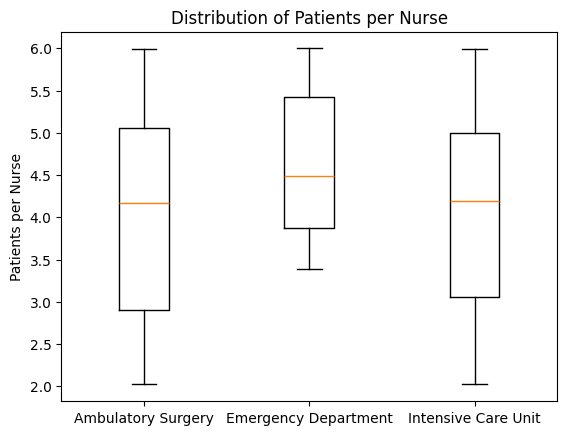

In [ ]:
nominal_as = nurse_count[0].X
nominal_ed = nurse_count[1].X
nominal_icu = nurse_count[2].X

as_patients = []
ed_patients = []
icu_patients = []

for i in range(100):
  as_patients.append(random.uniform(8, 24) / nominal_as)
  ed_patients.append(random.uniform(40, 72) / nominal_ed)
  icu_patients.append(random.uniform(8, 24) / nominal_icu)

data = [as_patients, ed_patients, icu_patients]

plt.boxplot(data, labels=departments)
plt.ylabel("Patients per Nurse")
plt.title("Distribution of Patients per Nurse")
plt.show()